# Earth radiation balance
---
## Procesy Transportu
The equilibrium between incoming solar radiation and outgoing terrestrial radiation:
- The Sun emits shortwave radiation that reaches Earth.
- Earth absorbs some of this energy and re-emits it as longwave (infrared) radiation.

Albedo, greenhouse gases, clouds.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy.solvers import solve
from sympy import Symbol
from scipy.optimize import fsolve
from functools import partial
from open_atmos_jupyter_utils import show_plot
from pint import UnitRegistry

si = UnitRegistry()
si.setup_matplotlib()

In [2]:
sunny_earth_surface = 255.0e6 * si.m**2
solar_constant = 1366.8 * si.W / si.m**2
albedo_mean = 0.3 * si.dimensionless
boltzmann_constant = 5.67e-8 * si.W / si.m**2 / si.K**4
solar_power_that_earth_gains = (
    sunny_earth_surface * solar_constant * (1 - albedo_mean)
) / 4

First part
---

In [3]:
T = Symbol("T")
temperature = (
    float(
        solve(
            -solar_power_that_earth_gains
            + boltzmann_constant * sunny_earth_surface * T**4 * si.K**4,
            T,
        )[1]
    )
    * si.K
)
print(f"Solar power: {solar_power_that_earth_gains:.4g}")
print(f"Temperature: {temperature:.4g} ")

Solar power: 6.099e+10 watt
Temperature: 254.9 kelvin 


Second part
---

In [4]:
albedo_earth_shortwave = 0.19
albedo_atmos_shortwave = 0.3
transmission_atmos_shortwave = 0.53
transmission_atmos_longwave = 0.06
albedo_atmos_longwave = 0.31
c = 2.7 * si.W / si.m**2 / si.K

In [5]:
def equations(vars, solar_constant):
    """System of equations for Earth surface temperature and temperature of the atmosphere"""
    T_surface, T_atmos = vars * si.K
    eq1 = (
        -transmission_atmos_shortwave
        * (1 - albedo_earth_shortwave)
        * solar_constant
        / 4
        + c * (T_surface - T_atmos)
        + boltzmann_constant * (T_surface**4 * (1 - albedo_atmos_longwave) - T_atmos**4)
    ).magnitude
    eq2 = (
        -(
            1
            - albedo_atmos_shortwave
            - transmission_atmos_shortwave * (1 - albedo_earth_shortwave)
        )
        * solar_constant
        / 4
        - c * (T_surface - T_atmos)
        - boltzmann_constant
        * (
            T_surface**4 * (1 - transmission_atmos_longwave - albedo_atmos_longwave)
            - 2 * T_atmos**4
        )
    ).magnitude
    return [eq1, eq2]

In [6]:
n = 100
solar_constants = np.linspace(0.8 * solar_constant, 1.2 * solar_constant, n)
solution = np.zeros((2, n))
for idx, solar_const in enumerate(solar_constants):
    solution[:, idx] = fsolve(
        partial(equations, solar_constant=solar_const), np.array([250, 290])
    )
earth_temperature, atmos_temperature = solution * si.K

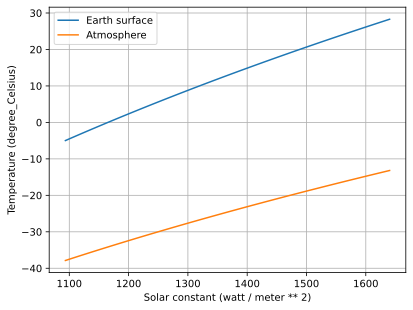

In [7]:
plt.plot(solar_constants, earth_temperature.to(si.degC), label="Earth surface")
plt.plot(solar_constants, atmos_temperature.to(si.degC), label="Atmosphere")
plt.xlabel(f"Solar constant ({si.W / si.m**2})")
plt.ylabel(f"Temperature ({si.degC})")
plt.grid()
plt.legend()

show_plot("solution")